# CICIDS-2017 EDA & Preprocessing for CM-MTD Architecture

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

import glob
import os

# Set display options for comprehensive EDA
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

In [2]:
# dataset_path = '../dataset/cicids2017/' 

# # Use glob to grab all .csv files in the directory
# all_files = glob.glob(os.path.join(dataset_path, "*.csv"))

# print(f"Found {len(all_files)} files. Beginning merge...")

# # List to hold the individual DataFrames
# df_list = []

# for file in all_files:
#     # Read each file
#     print(f"Reading {os.path.basename(file)}...")
#     df = pd.read_csv(file)
    
#     # CICIDS-2017 is notorious for having leading/trailing spaces in column names.
#     # Stripping them here prevents misalignment when concatenating.
#     df.columns = df.columns.str.strip()
    
#     df_list.append(df)

# # Concatenate all DataFrames into one massive DataFrame
# combined_df = pd.concat(df_list, axis=0, ignore_index=True)

# print(f"\nMerge complete! Total rows: {combined_df.shape[0]}, Total columns: {combined_df.shape[1]}")

# # Save the combined DataFrame to a single CSV file
# output_filename = 'cicids2017_combined.csv'
# combined_df.to_csv(output_filename, index=False)

# print(f"Successfully saved as {output_filename}")

Dataset loaded successfully. Shape: (2830743, 79)
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flo

None

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.829385e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2.830743e+06,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,8.708495e+02,4.104958e+01,3.059493e+02,3.353257e+02,inf,inf,1.298449e+06,2.919271e+06,9.182475e+06,1.623796e+05,1.448296e+07,2.610193e+06,3.266957e+06,9.042939e+06,1.021893e+06,9.893830e+06,1.805784e+06,1.485973e+06,4.684692e+06,9.672614e+05,4.644646e-02,0.0,1.112782e-04,0.0,-2.599739e+04,-2.273275e+03,6.386535e+04,6.995192e+03,1.643450e+01,9.504024e+02,1.719444e+02,2.949756e+02,4.861548e+05,3.537976e-02,4.644646e-02,2.423392e-04,2.980705e-01,3.158443e-01,9.482316e-02,1.112782e-04,2.433990e-04,6.835004e-01,1.919837e+02,5.820194e+01,3.059493e+02,-2.599739e+04,0.0,0.0,0.0,0.0,0.0,0.0,9.361160e+00,5.492919e+02,1.039377e+01,1.616230e+04,6.989837e+03,1.989433e+03,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,1.946367e+03,6.886260e+01,6.052568e+02,8.396932e+02,NaN,NaN,4.507944e+06,8.045870e+06,2.445954e+07,2.950282e+06,3.357581e+07,9.525722e+06,9.639055e+06,2.452916e+07,8.591436e+06,2.873661e+07,8.887197e+06,6.278469e+06,1.716095e+07,8.308983e+06,2.104500e-01,0.0,1.054826e-02,0.0,2.105286e+07,1.452209e+06,2.475371e+05,3.815170e+04,2.523772e+01,2.028229e+03,3.054915e+02,6.318001e+02,1.647490e+06,1.847378e-01,2.104500e-01,1.556536e-02,4.574107e-01,4.648513e-01,2.929706e-01,1.054826e-02,1.559935e-02,6.804920e-01,3.318603e+02,1.860912e+02,6.052568e+02,2.105286e+07,0.0,0.0,0.0,0.0,0.0,0.0,7.496728e+02,9.980070e+03,9.973883e+02,2.26305

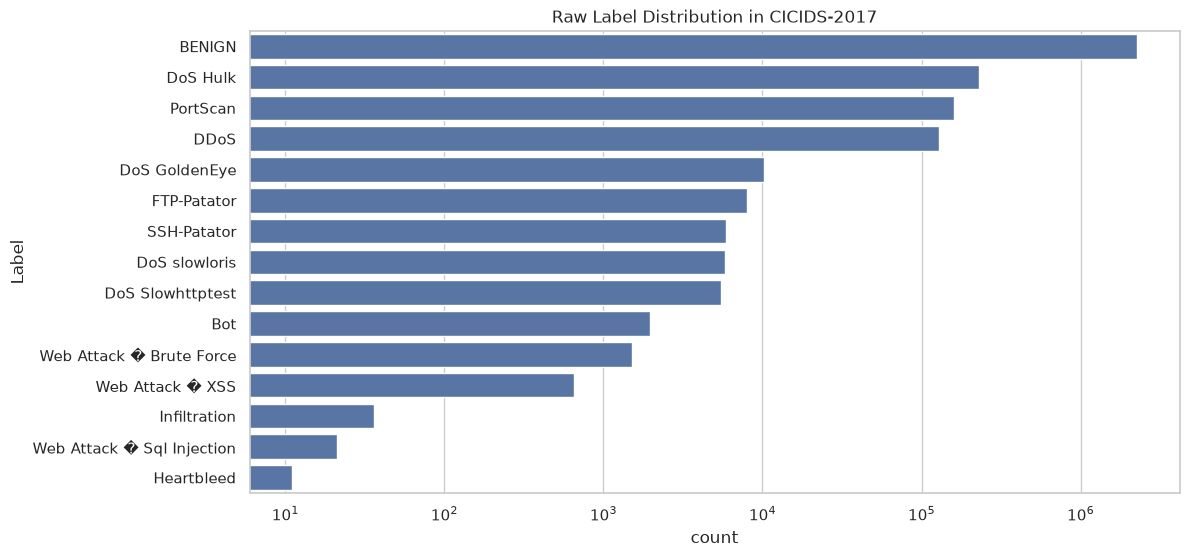

In [3]:
# Load and Inspect
# Replace with your local path to the dataset
file_path = '../dataset/cicids2017/cicids2017_combined.csv' 

try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Please ensure the path is correct.")
    # Creating a dummy dataframe to allow the notebook to run for demonstration
    # In practice, load the actual CICIDS2017 CSVs here.
    pass 

# Strip leading/trailing whitespaces from column names (Common issue in CICIDS-2017)
df.columns = df.columns.str.strip()

# Display basic info
display(df.info())
display(df.describe())

# Check the distribution of the raw labels
plt.figure(figsize=(12, 6))
sns.countplot(y=df['Label'], order=df['Label'].value_counts().index)
plt.title('Raw Label Distribution in CICIDS-2017')
plt.xscale('log') # Log scale due to heavy class imbalance
plt.show()

In [4]:
# Map and Filter Target Classes
# Define mapping dictionary
label_mapping = {
    'BENIGN': 'Benign',
    'DoS Hulk': 'DoS/DDoS',
    'DoS GoldenEye': 'DoS/DDoS',
    'DoS slowloris': 'DoS/DDoS',
    'DoS Slowhttptest': 'DoS/DDoS',
    'DDoS': 'DoS/DDoS',
    'Infiltration': 'Infiltration'
}

# Apply mapping; unmapped labels become NaN
df['Target'] = df['Label'].map(label_mapping)

# Drop rows that do not fall into the three categories evaluated in the paper
df = df.dropna(subset=['Target'])
df = df.drop(columns=['Label'])

print("Filtered Label Distribution:")
print(df['Target'].value_counts())

# Encode the target classes for the LSTM/Softmax layer
le = LabelEncoder()
df['Target_Encoded'] = le.fit_transform(df['Target'])
print("\nClass Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Filtered Label Distribution:
Target
Benign          2273097
DoS/DDoS         380688
Infiltration         36
Name: count, dtype: int64

Class Mapping: {'Benign': np.int64(0), 'DoS/DDoS': np.int64(1), 'Infiltration': np.int64(2)}


In [5]:
# Data Cleaning (Handling Inf and NaN)
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100
print("Missing values per feature (%):\n", missing_percentages[missing_percentages > 0])

# Strategy: Drop rows with NaN (Best practice for CICIDS-2017 since NaNs are usually < 1%)
df.dropna(inplace=True)
print(f"\nShape after dropping NaNs: {df.shape}")


Missing values per feature (%):
 Flow Bytes/s      0.102795
Flow Packets/s    0.102795
dtype: float64

Shape after dropping NaNs: (2651093, 80)


## Feature Selection & Dimensionality Reduction
The paper mentions mapping events into a "low dimensional space"[cite: 326]. High-dimensional, highly correlated features degrade DRL convergence and cause state-space explosion. 

We will:
1. Drop metadata/string columns not usable by the network (e.g., IPs, though in a real SDN controller, IPs are used for routing, the neural network requires numerical features).
2. Remove Zero-Variance features.
3. Remove highly correlated features (Pearson correlation > 0.90) to reduce redundancy.

In [6]:
# Apply Feature Selection
# Separate features and target
X = df.drop(columns=['Target', 'Target_Encoded'])
y = df['Target_Encoded']

# 1. Drop non-numeric features if any remain (e.g., Flow ID, Source IP, Destination IP)
# *Note: The paper notes node ID and timestamp are used. If retaining timestamps, 
# convert them to UNIX epoch or cyclical time features (sin/cos).*
cols_to_drop = X.select_dtypes(include=['object']).columns
X = X.drop(columns=cols_to_drop)

# 2. Remove constant features (Zero Variance)
selector = VarianceThreshold(threshold=0.0)
selector.fit(X)
X_var = X.loc[:, selector.get_support()]
print(f"Features removed due to zero variance: {X.shape[1] - X_var.shape[1]}")

# 3. Remove highly correlated features
corr_matrix = X_var.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

X_final = X_var.drop(columns=to_drop_corr)
print(f"Features removed due to high correlation (>0.90): {len(to_drop_corr)}")
print(f"Final feature count for environment state: {X_final.shape[1]}")

Features removed due to zero variance: 8
Features removed due to high correlation (>0.90): 30
Final feature count for environment state: 40


In [7]:
# Split and Scale
# 80/20 Train-Test Split as specified by the paper
# X_train, X_test, y_train, y_test = train_test_split(
#     X_final, y, test_size=0.20, random_state=42, stratify=y
# )
split_idx = int(len(df) * 0.8)
print(f'Dataframe Length: {len(df)}')
X_train, X_test = X_final[:split_idx], X_final[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Train class counts:", np.bincount(y_train))
print("Test class counts: ", np.bincount(y_test))


Dataframe Length: 2651093
Train class counts: [1741101  379737      36]
Test class counts:  [530219]


In [8]:
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Scale the features
scaler = StandardScaler()

# Fit on training data ONLY to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling if passing to a custom Gym environment
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_final.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_final.columns)

display(X_train_scaled_df.head())

Training set size: (2120874, 40)
Testing set size: (530219, 40)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Min,Fwd IAT Mean,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Idle Std
0,-0.407621,2.702250,0.043806,0.807857,0.215099,-0.291199,0.663384,-0.061463,3.975260,-0.059215,-0.279543,0.014067,0.119311,-0.057911,-0.064191,-0.123273,3.435324,0.316944,0.755774,0.589690,4.488329,-0.012188,0.001182,0.002147,-0.156764,-0.646394,-0.209815,-0.015675,-0.595386,1.374364,-0.325942,-0.905008,-0.414133,0.018536,0.022313,0.002509,0.164470,1.273657,1.369388,0.696296
1,-0.407621,2.712891,0.067212,0.958920,0.215099,-0.291199,0.496653,0.037961,1.229635,-0.059213,-0.279542,-0.096995,0.030110,-0.057911,-0.135424,-0.123273,3.435324,0.098987,0.590173,0.589690,4.488329,-0.012188,0.001209,0.002617,-0.156760,-0.646394,-0.209815,-0.015675,-0.595386,1.374364,-0.325942,-0.905008,-0.427065,0.018775,0.044075,0.002509,0.127043,1.100405,1.177824,0.687089
2,-0.428843,2.894957,0.163176,-0.053274,-0.295283,-0.291199,-0.315720,-0.486318,-0.591147,-0.059222,-0.279541,-0.150294,0.196786,-0.057912,-0.224247,-0.123274,-0.361074,-0.216583,-0.253833,-0.290383,-0.222800,-0.012188,0.001116,0.001441,-0.156771,-0.646394,-0.209815,-0.015675,-0.595386,-0.727609,-0.325942,-0.905008,-0.455000,-0.230168,-0.008970,0.002473,9.945883,27.889695,18.921645,4.526586
3,-0.404675,1.215925,-0.001835,0.154259,1.088953,-0.291199,0.942761,0.185717,-0.591147,-0.059217,-0.279544,0.519853,1.360459,-0.057912,0.448222,-0.123239,-0.353954,-0.212750,-0.249913,-0.287337,-0.222800,-0.012188,0.001124,0.001581,-0.156767,-0.646394,-0.209815,-0.015675,1.679582,-0.727609,-0.325942,-0.905008,0.130362,-0.168709,0.001911,0.002496,-0.133074,-0.104111,-0.153957,-0.121996
4,-0.425952,-0.479369,-0.010027,-0.044189,-0.230693,0.472240,-0.067805,-0.412210,1.735408,0.000336,-0.223762,-0.318206,-0.404017,-0.057911,-0.304711,-0.123273,-0.361074,-0.216582,-0.253833,-0.290383,-0.222800,-0.012188,0.001119,0.001500,0.064471,1.343084,-0.209815,-0.015675,-0.595386,-0.727609,-0.325942,0.469320,-0.455000,-0.230168,-0.007610,0.002509,-0.133074,-0.104111,-0.153957,-0.121996


In [9]:
# # 6. Apply SMOTE to the training data
# print(f"Class distribution before SMOTE: {Counter(y_train)}")

# # Use Pipeline of SMOTE and RandomUnderSampler to handle oversampling of minority and undersampling of majority class
# # smote = SMOTE(random_state=42)

# pipeline = Pipeline([
#     ('under', RandomUnderSampler(
#         # sampling_strategy={'BENIGN': 200000},
#         sampling_strategy={0: 300000,
#                            1: 300000},
#         random_state=42
#     )),
#     ('smote', SMOTE(
#         sampling_strategy={
#             2: 300000
#         },
#         random_state=42
#     ))
# ])

# X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train_scaled, y_train)

# print(f"Class distribution after SMOTE: {Counter(y_train_resampled)}")

In [10]:
# Save Data
# Save the preprocessed arrays for the DRL pipeline
np.save('../dataset/cicids2017/X_train_env_state.npy', X_train_scaled)
np.save('../dataset/cicids2017/X_test_env_state.npy', X_test_scaled)
np.save('../dataset/cicids2017/y_train_env_state.npy', y_train)
np.save('../dataset/cicids2017/y_test_env_state.npy', y_test)

print("Preprocessing complete. Data saved for LSTM/HDRL ingestion.")

Preprocessing complete. Data saved for LSTM/HDRL ingestion.
